<a href="https://colab.research.google.com/github/Harsh-Burande/macroeconomics_stability_and_well_being_analytics/blob/main/Macroeconomics_Stability_%26_Well_Being_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

from imblearn.over_sampling import SMOTE


from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Load DataFrame**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Macroeconomics Stability & Well-Being Analytics/WHI_Inflation.csv')

In [ ]:
df.head(5)

,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,Afghanistan,2015,-0.660,-4.250000,-0.840000,0.219999,NaN,2.665090,South Asia,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190
1,Afghanistan,2016,4.380,2.070000,5.670000,5.192760,NaN,-2.409509,South Asia,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120
2,Afghanistan,2017,4.976,4.440000,6.940000,5.423228,NaN,2.404000,South Asia,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158
3,Afghanistan,2018,0.630,1.474185,-1.045952,-0.126033,NaN,2.071208,South Asia,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000
4,Afghanistan,2019,2.302,-2.494359,3.794770,NaN,NaN,6.520928,South Asia,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1232 non-null   object 
 1   Year                                    1232 non-null   int64  
 2   Headline Consumer Price Inflation       1200 non-null   float64
 3   Energy Consumer Price Inflation         1090 non-null   float64
 4   Food Consumer Price Inflation           1130 non-null   float64
 5   Official Core Consumer Price Inflation  734 non-null    float64
 6   Producer Price Inflation                769 non-null    float64
 7   GDP deflator Index growth rate          1211 non-null   float64
 8   Continent/Region                        1232 non-null   object 
 9   Score                                   1232 non-null   float64
 10  GDP per Capita                          1232 non-null   floa

In [ ]:
df.describe()

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
count,1232.000000,1200.000000,1090.000000,1130.000000,734.000000,769.000000,1211.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1231.000000
mean,2018.895292,7.395445,6.424233,8.030094,3.512612,5.841887,7.070015,5.499001,1.030767,1.056623,0.588755,0.459393,0.196145,0.133454
std,2.554602,25.165914,16.591503,26.170251,5.513661,13.679284,31.623180,1.135263,0.452230,0.332605,0.244042,0.155579,0.112531,0.115169
min,2015.000000,-3.752996,-23.879999,-22.030001,-28.619415,-83.339781,-26.100000,1.859000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,1.402264,0.607611,1.264364,1.041840,-0.283404,1.352541,4.624650,0.736952,0.859935,0.407759,0.370090,0.117000,0.055902
50%,2019.000000,3.476146,2.769178,3.728997,2.245673,2.729256,3.244246,5.538950,1.051500,1.093500,0.617830,0.481000,0.183000,0.098000
75%,2021.000000,6.875713,7.101345,9.293584,4.626995,8.433447,7.079739,6.335750,1.343000,1.313843,0.781501,0.575416,0.252000,0.171000
max,2023.000000,557.210000,306.431673,601.020236,58.851863,128.476638,812.247463,7.842000,2.209000,1.644000,1.141000,0.772000,0.838075,0.587000


In [ ]:
df.columns

Index(['Country', 'Year', 'Headline Consumer Price Inflation',
       'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
       'Official Core Consumer Price Inflation', 'Producer Price Inflation',
       'GDP deflator Index growth rate', 'Continent/Region', 'Score',
       'GDP per Capita', 'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

## **Imputing nulls with country's median**

In [ ]:
inflation_cols = ['Headline Consumer Price Inflation', 'Energy Consumer Price Inflation',
        'Food Consumer Price Inflation', 'Official Core Consumer Price Inflation',
        'Producer Price Inflation', 'GDP deflator Index growth rate']

for col in inflation_cols:
  df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))
  df[col].fillna(df[col].median(), inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1232 non-null   object 
 1   Year                                    1232 non-null   int64  
 2   Headline Consumer Price Inflation       1232 non-null   float64
 3   Energy Consumer Price Inflation         1232 non-null   float64
 4   Food Consumer Price Inflation           1232 non-null   float64
 5   Official Core Consumer Price Inflation  1232 non-null   float64
 6   Producer Price Inflation                1232 non-null   float64
 7   GDP deflator Index growth rate          1232 non-null   float64
 8   Continent/Region                        1232 non-null   object 
 9   Score                                   1232 non-null   float64
 10  GDP per Capita                          1232 non-null   floa

In [ ]:
df['Perceptions of corruption'] = df.groupby('Country')['Perceptions of corruption'].fillna(df['Perceptions of corruption'].median())

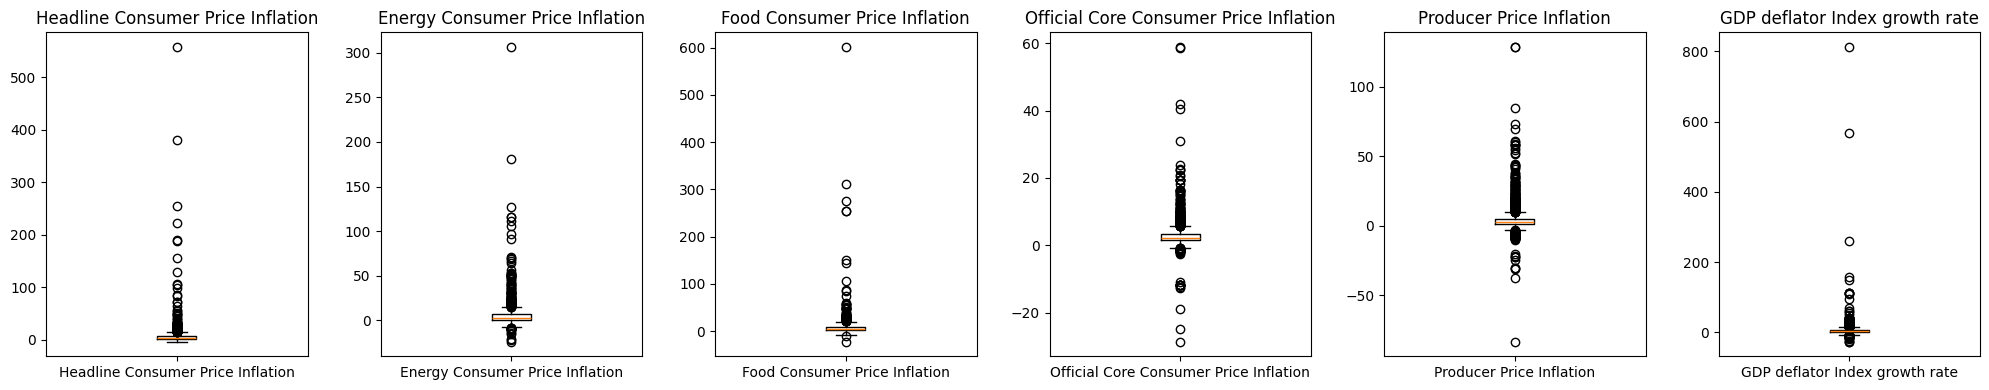

In [ ]:
fig, axes = plt.subplots(1, len(inflation_cols), figsize=(20, 4))

# 2. Loop through the columns and their corresponding subplot axes
for i, col in enumerate(inflation_cols):
    axes[i].boxplot(df[col].dropna()) # Using .dropna() prevents empty plot errors
    axes[i].set_title(col)
    axes[i].set_xticklabels([col])   # Optional: labels the x-axis with column name

# 3. Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000
mean,2018.895292,7.294815,6.121553,7.986121,2.985936,4.834403,7.003533,5.499001,1.030767,1.056623,0.588755,0.459393,0.196145,0.133425
std,2.554602,24.844337,15.821164,25.248469,4.602632,11.154673,31.356433,1.135263,0.452230,0.332605,0.244042,0.155579,0.112531,0.115126
min,2015.000000,-3.752996,-23.879999,-22.030001,-28.619415,-83.339781,-26.100000,1.859000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,1.442750,0.843467,1.427445,1.658370,1.494757,1.365425,4.624650,0.736952,0.859935,0.407759,0.370090,0.117000,0.055951
50%,2019.000000,3.483881,2.800890,3.840168,2.245420,2.794002,3.241045,5.538950,1.051500,1.093500,0.617830,0.481000,0.183000,0.098000
75%,2021.000000,6.728402,6.492886,9.083294,3.289196,4.721640,6.978955,6.335750,1.343000,1.313843,0.781501,0.575416,0.252000,0.171000
max,2023.000000,557.210000,306.431673,601.020236,58.851863,128.476638,812.247463,7.842000,2.209000,1.644000,1.141000,0.772000,0.838075,0.587000


## **Signed Logarithmic Transformation**

In [ ]:
def signed_log(x):
    return np.sign(x) * np.log1p(abs(x))

for col in inflation_cols:
    df[col] = df[col].apply(signed_log)

df.isna().sum()

,0
Country,0
Year,0
Headline Consumer Price Inflation,0
Energy Consumer Price Inflation,0
Food Consumer Price Inflation,0
Official Core Consumer Price Inflation,0
Producer Price Inflation,0
GDP deflator Index growth rate,0
Continent/Region,0
Score,0


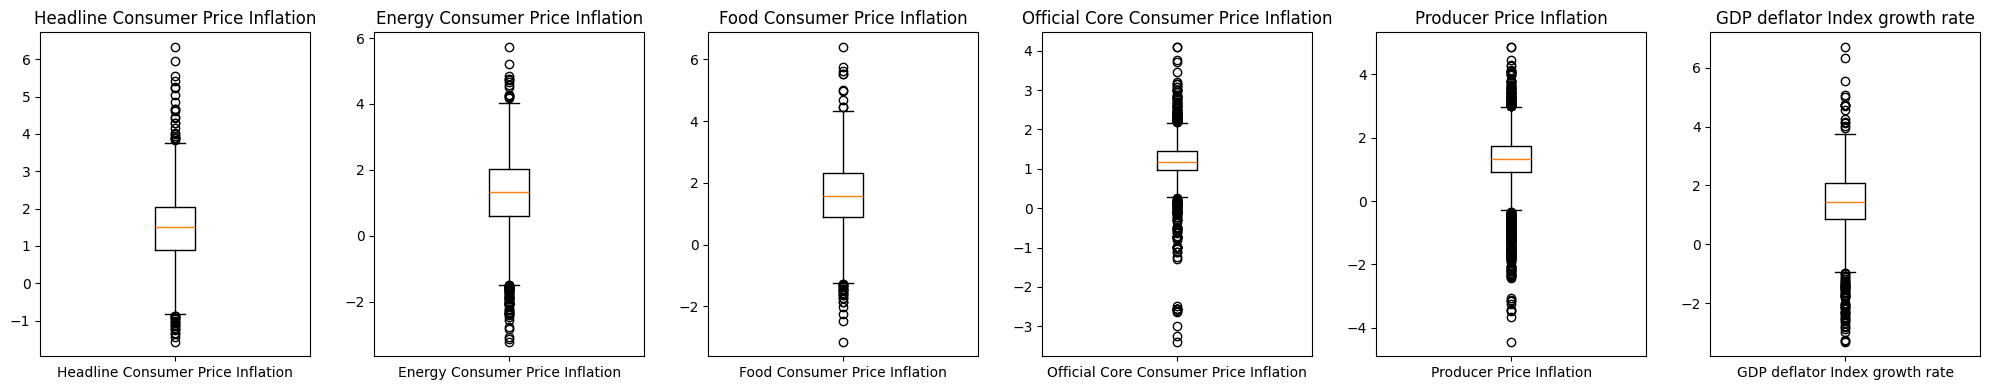

In [ ]:
fig, axes = plt.subplots(1, len(inflation_cols), figsize=(20, 4))

# 2. Loop through the columns and their corresponding subplot axes
for i, col in enumerate(inflation_cols):
    axes[i].boxplot(df[col].dropna()) # Using .dropna() prevents empty plot errors
    axes[i].set_title(col)
    axes[i].set_xticklabels([col])   # Optional: labels the x-axis with column name

# 3. Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

# **Checking Outliers**

In [ ]:
print(f"{"Quartile_1":>8} {"Quartile_3":>8} {"Inter_Quartile_Range":>5} {"Lower_Bound":>8} {"Upper_Bound":>8}")
for col in inflation_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bnd = q1-1.5*iqr
  upper_bnd = q3+1.5*iqr

  print(f"{q1:>10.2f} {q3:>10.2f} {iqr:>20.2f} {lower_bnd:>11.2f} {upper_bnd:>11.2f}")

Quartile_1 Quartile_3 Inter_Quartile_Range Lower_Bound Upper_Bound
      0.89       2.04                 1.15       -0.83        3.77
      0.61       2.01                 1.40       -1.49        4.12
      0.89       2.31                 1.42       -1.25        4.45
      0.98       1.46                 0.48        0.26        2.17
      0.91       1.74                 0.83       -0.33        2.99
      0.86       2.08                 1.22       -0.96        3.90


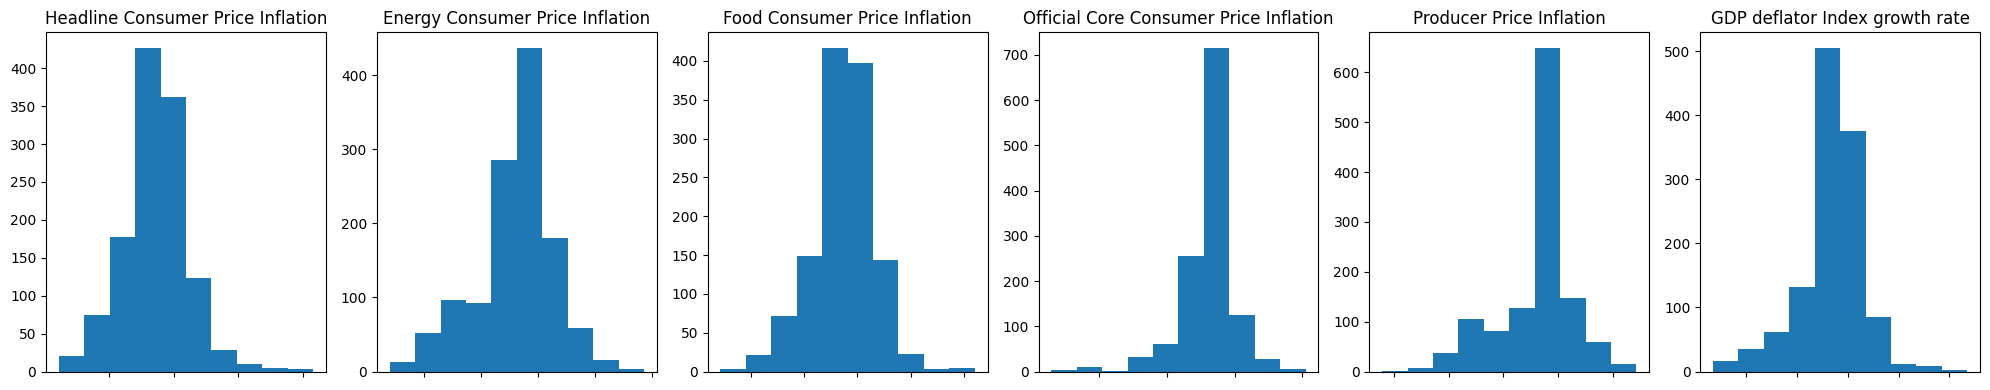

In [ ]:
fig, axes = plt.subplots(1, len(inflation_cols), figsize=(20, 4))

# 2. Loop through the columns and their corresponding subplot axes
for i, col in enumerate(inflation_cols):
    axes[i].hist(df[col].dropna()) # Using .dropna() prevents empty plot errors
    axes[i].set_title(col)
    axes[i].set_xticklabels([col])   # Optional: labels the x-axis with column name

# 3. Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
df

,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,Afghanistan,2015,-0.506818,-1.658228,-0.609766,0.198850,1.333421,1.298853,South Asia,3.5750,0.319820,0.302850,0.303350,0.234140,0.365100,0.097190
1,Afghanistan,2016,1.682688,1.121678,1.897620,1.823381,1.333421,-1.226568,South Asia,3.3600,0.382270,0.110370,0.173440,0.164300,0.312680,0.071120
2,Afghanistan,2017,1.787751,1.693779,2.071913,1.859921,1.333421,1.224951,South Asia,3.7940,0.401477,0.581543,0.180747,0.106180,0.311871,0.061158
3,Afghanistan,2018,0.488580,0.905911,-0.715863,-0.118700,1.333421,1.122071,South Asia,3.6320,0.332000,0.537000,0.255000,0.085000,0.191000,0.036000
4,Afghanistan,2019,1.194528,-1.251150,1.567526,1.310056,1.333421,2.017690,South Asia,3.2030,0.350000,0.517000,0.361000,0.000000,0.158000,0.025000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,Zimbabwe,2019,5.546317,4.519700,4.467337,1.177245,1.333421,-1.616460,Sub-Saharan Africa,3.6630,0.366000,1.114000,0.433000,0.361000,0.151000,0.089000
1228,Zimbabwe,2020,6.324735,5.728253,6.400291,1.177245,1.333421,6.345587,Sub-Saharan Africa,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929
1229,Zimbabwe,2021,4.600620,4.260141,4.670958,1.177245,1.333421,4.738783,Sub-Saharan Africa,3.1450,0.457000,0.649000,0.243000,0.359000,0.157000,0.075000
1230,Zimbabwe,2022,4.660654,4.587480,5.017061,1.177245,1.333421,4.736360,Sub-Saharan Africa,2.9950,0.947000,0.690000,0.270000,0.329000,0.106000,0.105000


In [ ]:
# Columns wise count of values less than 0

for col in inflation_cols:
  print(f"{col:} {(df[col] < 0).sum()}")

Headline Consumer Price Inflation 95
Energy Consumer Price Inflation 212
Food Consumer Price Inflation 125
Official Core Consumer Price Inflation 71
Producer Price Inflation 222
GDP deflator Index growth rate 130


In [ ]:
df.isna().sum()

,0
Country,0
Year,0
Headline Consumer Price Inflation,0
Energy Consumer Price Inflation,0
Food Consumer Price Inflation,0
Official Core Consumer Price Inflation,0
Producer Price Inflation,0
GDP deflator Index growth rate,0
Continent/Region,0
Score,0


## **Dropping null rows**

In [ ]:
df = df.dropna()

## **Duplicate check**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1232 non-null   object 
 1   Year                                    1232 non-null   int64  
 2   Headline Consumer Price Inflation       1232 non-null   float64
 3   Energy Consumer Price Inflation         1232 non-null   float64
 4   Food Consumer Price Inflation           1232 non-null   float64
 5   Official Core Consumer Price Inflation  1232 non-null   float64
 6   Producer Price Inflation                1232 non-null   float64
 7   GDP deflator Index growth rate          1232 non-null   float64
 8   Continent/Region                        1232 non-null   object 
 9   Score                                   1232 non-null   float64
 10  GDP per Capita                          1232 non-null   floa

# **EDA**

In [ ]:
df.columns

Index(['Country', 'Year', 'Headline Consumer Price Inflation',
       'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
       'Official Core Consumer Price Inflation', 'Producer Price Inflation',
       'GDP deflator Index growth rate', 'Continent/Region', 'Score',
       'GDP per Capita', 'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

## **GDP vs Happiness**

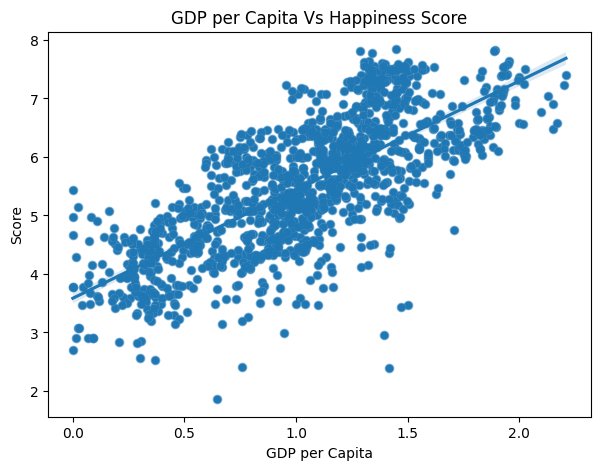

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='GDP per Capita', y='Score')
sns.regplot(data=df, x='GDP per Capita', y='Score', scatter_kws={'alpha':0.5})
plt.title('GDP per Capita Vs Happiness Score')
plt.show()

In [ ]:
df[['GDP per Capita', 'Score']].corr()

,GDP per Capita,Score
GDP per Capita,1.000000,0.739683
Score,0.739683,1.000000


**GDP per capita shows a strong positive relationship with happiness score,
but the relationship is non-linear, exhibiting diminishing returns at higher income levels.
Additionally, variability in happiness among countries with similar GDP indicates
that non-economic factors such as social support and governance play a significant role.**



**GDP determines the capacity for happiness, but social and institutional factors determine the realization of happiness.**

## **Inflation Vs Happiness Score**

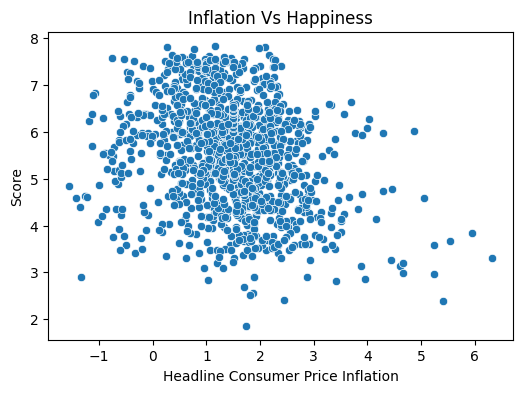

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Headline Consumer Price Inflation', y='Score')
plt.title('Inflation Vs Happiness')
plt.show()

In [ ]:
df[['Headline Consumer Price Inflation', 'Score']].corr()

,Headline Consumer Price Inflation,Score
Headline Consumer Price Inflation,1.00000,-0.26855
Score,-0.26855,1.00000


**Countries with similar inflation levels exhibit a wide range of happiness scores,
indicating that inflation alone is not a strong determinant of well-being.
While extremely high inflation appears to be associated with lower happiness,
the overall relationship is weak and non-linear, suggesting that structural and social factors play a more significant role.**

## **Correlation Heatmap**

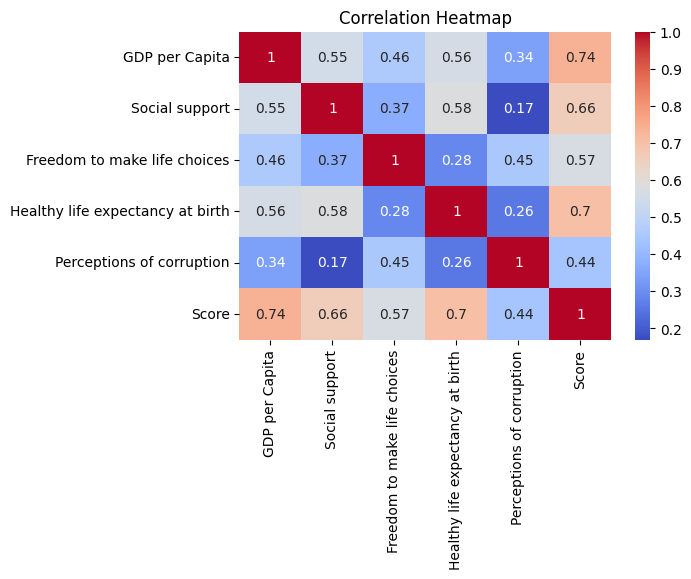

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['GDP per Capita', 'Social support', 'Freedom to make life choices', 'Healthy life expectancy at birth', 'Perceptions of corruption', 'Score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

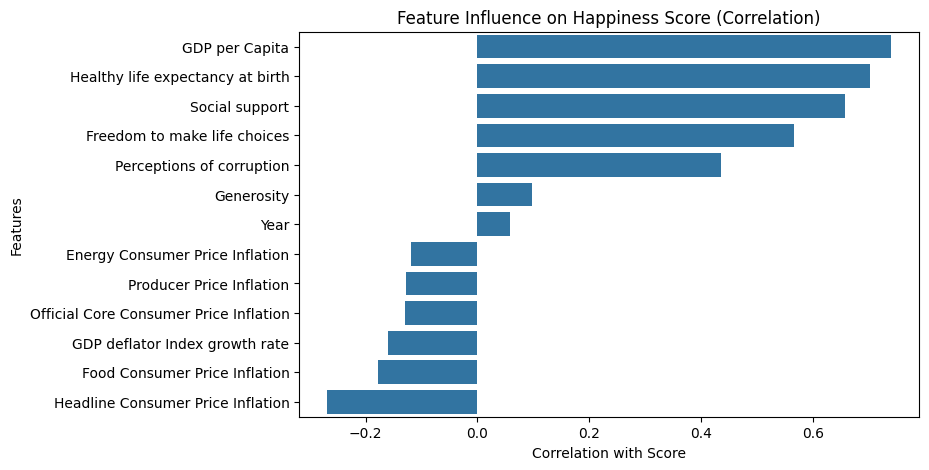

In [ ]:
corr = df.corr(numeric_only=True)['Score'].drop('Score').sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Feature Influence on Happiness Score (Correlation)")
plt.xlabel("Correlation with Score")
plt.ylabel("Features")
plt.show()

**Happiness is primarily driven by structural factors such as economic prosperity,
health, and social support, while inflation shows weak direct correlation.
This suggests that short-term economic fluctuations have limited standalone impact
on well-being unless combined with underlying systemic weaknesses.**

## **Happiness Risk Classification**

In [ ]:
df['risk_level'] = pd.cut(
    df['Score'],
    bins=[-np.inf, 5, 7, np.inf],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

In [ ]:
df['risk_level'].value_counts().reset_index()

,risk_level,count
0,Medium Risk,686
1,High Risk,413
2,Low Risk,133


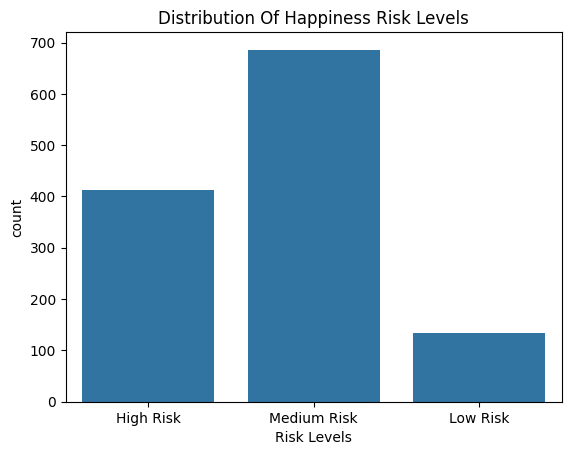

In [ ]:
sns.countplot(data=df, x='risk_level')
plt.title('Distribution Of Happiness Risk Levels')
plt.xlabel('Risk Levels')
plt.show()

In [ ]:
df.groupby('risk_level')['Score'].describe().reset_index()

,risk_level,count,mean,std,min,25%,50%,75%,max
0,High Risk,413.0,4.212793,0.556692,1.859,3.808,4.3500,4.628000,4.996
1,Medium Risk,686.0,5.916541,0.541119,5.003,5.434,5.9425,6.347225,6.994
2,Low Risk,133.0,7.339386,0.194139,7.006,7.183,7.3240,7.494000,7.842


**We transformed continuous happiness scores into discrete risk categories to identify countries at risk of low well-being, enabling targeted policy and economic interventions.**

# **Baseline Model Training**
Only Macroeconomic Features (inflations)

## **Copying df for model training**

In [ ]:
df_model = df.copy()

leakage_cols = ['GDP per Capita', 'Social support',
                'Healthy life expectancy at birth',
                'Freedom to make life choices', 'Generosity',
                'Perceptions of corruption']

df_model = df_model.drop(columns=leakage_cols)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   Country                                 1232 non-null   object  
 1   Year                                    1232 non-null   int64   
 2   Headline Consumer Price Inflation       1232 non-null   float64 
 3   Energy Consumer Price Inflation         1232 non-null   float64 
 4   Food Consumer Price Inflation           1232 non-null   float64 
 5   Official Core Consumer Price Inflation  1232 non-null   float64 
 6   Producer Price Inflation                1232 non-null   float64 
 7   GDP deflator Index growth rate          1232 non-null   float64 
 8   Continent/Region                        1232 non-null   object  
 9   Score                                   1232 non-null   float64 
 10  risk_level                              1232 non

In [ ]:
df_model

,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,risk_level
0,Afghanistan,2015,-0.506818,-1.658228,-0.609766,0.198850,1.333421,1.298853,South Asia,3.5750,High Risk
1,Afghanistan,2016,1.682688,1.121678,1.897620,1.823381,1.333421,-1.226568,South Asia,3.3600,High Risk
2,Afghanistan,2017,1.787751,1.693779,2.071913,1.859921,1.333421,1.224951,South Asia,3.7940,High Risk
3,Afghanistan,2018,0.488580,0.905911,-0.715863,-0.118700,1.333421,1.122071,South Asia,3.6320,High Risk
4,Afghanistan,2019,1.194528,-1.251150,1.567526,1.310056,1.333421,2.017690,South Asia,3.2030,High Risk
...,...,...,...,...,...,...,...,...,...,...,...
1227,Zimbabwe,2019,5.546317,4.519700,4.467337,1.177245,1.333421,-1.616460,Sub-Saharan Africa,3.6630,High Risk
1228,Zimbabwe,2020,6.324735,5.728253,6.400291,1.177245,1.333421,6.345587,Sub-Saharan Africa,3.2992,High Risk
1229,Zimbabwe,2021,4.600620,4.260141,4.670958,1.177245,1.333421,4.738783,Sub-Saharan Africa,3.1450,High Risk
1230,Zimbabwe,2022,4.660654,4.587480,5.017061,1.177245,1.333421,4.736360,Sub-Saharan Africa,2.9950,High Risk


## **Creating RandomForest Baseline Model**

Accuracy: 0.7247

Feature Importance 
                                    index         0
0  Official Core Consumer Price Inflation  0.188807
1                Producer Price Inflation  0.167897
2       Headline Consumer Price Inflation  0.157162
3         Energy Consumer Price Inflation  0.149086
4           Food Consumer Price Inflation  0.136403
5          GDP deflator Index growth rate  0.131901
6                                    Year  0.068742



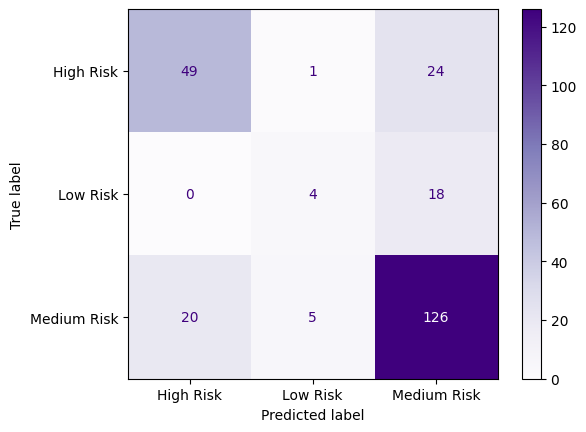

In [ ]:
X = df_model.drop(columns=['Score','risk_level','Continent/Region','Country'])
y = df_model['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm1 = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=model.classes_)
disp1.plot(cmap='Purples')

print(f"Accuracy: {acc:.4f}\n")

feature_importance = pd.Series(
    model.feature_importances_,
    index = X_train.columns
).sort_values(ascending=False).reset_index()

print(f"Feature Importance \n{feature_importance}\n")

**Macroeconomic inflation indicators have limited predictive power for happiness risk when used independently, highlighting the importance of social and structural factors in determining well-being.**

# **Feature Engineering**

In [ ]:
df[df['Country'] == 'India'][['GDP deflator Index growth rate', 'Year']]

,GDP deflator Index growth rate,Year
469,1.187791,2015
470,1.444055,2016
471,1.603329,2017
472,1.555453,2018
473,1.518533,2019
474,1.717580,2020
475,2.394838,2021
476,2.272216,2022
477,1.194046,2023


In [ ]:
df.columns

Index(['Country', 'Year', 'Headline Consumer Price Inflation',
       'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
       'Official Core Consumer Price Inflation', 'Producer Price Inflation',
       'GDP deflator Index growth rate', 'Continent/Region', 'Score',
       'GDP per Capita', 'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'risk_level'],
      dtype='object')

In [ ]:
df[df['Country'] == 'Oman']

,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,risk_level
852,Oman,2015,0.063241,0.350657,-0.595022,0.377064,-3.164335,-2.984608,Middle East and North Africa,6.853,1.36011,1.08182,0.76276,0.63274,0.21542,0.32524,Medium Risk


In [ ]:
df['Headline Consumer Price Inflation'].describe()

,Headline Consumer Price Inflation
count,1232.000000
mean,1.459854
std,1.009487
min,-1.558775
25%,0.893124
50%,1.500489
75%,2.044902
max,6.324735


## **Calculating Volatility Feature**

In [ ]:
df['previous_year_inflation'] = df.groupby('Country')['Headline Consumer Price Inflation'].shift(1)                                               # Creating previous_year_inflation column to derive inflation_volatility later
df_model['previous_year_inflation'] = df_model.groupby('Country')['Headline Consumer Price Inflation'].shift(1)                                   # Creating previous_year_inflation column to derive inflation_volatility later

df['previous_year_inflation'] = df['previous_year_inflation'].fillna(0)                                                                           # Filling nulls with 0 in previous_year_inflation
df_model['previous_year_inflation'] = df_model['previous_year_inflation'].fillna(0)                                                               # Filling nulls with 0 in previous_year_inflation

df_model[['Country','Year','Headline Consumer Price Inflation','previous_year_inflation']].head()

,Country,Year,Headline Consumer Price Inflation,previous_year_inflation
0,Afghanistan,2015,-0.506818,0.000000
1,Afghanistan,2016,1.682688,-0.506818
2,Afghanistan,2017,1.787751,1.682688
3,Afghanistan,2018,0.488580,1.787751
4,Afghanistan,2019,1.194528,0.488580


In [ ]:
# Calculated Inflation Change

df['Inflation_change'] = df['Headline Consumer Price Inflation'] - df['previous_year_inflation']
df_model['Inflation_change'] = df['Headline Consumer Price Inflation'] - df['previous_year_inflation']

In [ ]:
df_model[['Country','Year','Headline Consumer Price Inflation','previous_year_inflation','Inflation_change']].head()

,Country,Year,Headline Consumer Price Inflation,previous_year_inflation,Inflation_change
0,Afghanistan,2015,-0.506818,0.000000,-0.506818
1,Afghanistan,2016,1.682688,-0.506818,2.189506
2,Afghanistan,2017,1.787751,1.682688,0.105063
3,Afghanistan,2018,0.488580,1.787751,-1.299171
4,Afghanistan,2019,1.194528,0.488580,0.705948


In [ ]:
# Calculated Inflation_volatility feature to understand country wise inflation volatility by using STANDARD DAVIATION

df['Inflation_volatility'] = df.groupby('Country')['Inflation_change'].transform(lambda x: np.std(x, ddof=1))
df_model['Inflation_volatility'] = df.groupby('Country')['Inflation_change'].transform(lambda x: np.std(x, ddof=1))


# Filled null with 0 in inflation volatility feature
df['Inflation_volatility'] = df['Inflation_volatility'].fillna(0)
df_model['Inflation_volatility'] = df_model['Inflation_volatility'].fillna(0)

In [ ]:
df.isna().sum()

,0
Country,0
Year,0
Headline Consumer Price Inflation,0
Energy Consumer Price Inflation,0
Food Consumer Price Inflation,0
Official Core Consumer Price Inflation,0
Producer Price Inflation,0
GDP deflator Index growth rate,0
Continent/Region,0
Score,0


In [ ]:
df_model[['Country','Year','Headline Consumer Price Inflation','previous_year_inflation','Inflation_change','Inflation_volatility']].head()

,Country,Year,Headline Consumer Price Inflation,previous_year_inflation,Inflation_change,Inflation_volatility
0,Afghanistan,2015,-0.506818,0.000000,-0.506818,1.018274
1,Afghanistan,2016,1.682688,-0.506818,2.189506,1.018274
2,Afghanistan,2017,1.787751,1.682688,0.105063,1.018274
3,Afghanistan,2018,0.488580,1.787751,-1.299171,1.018274
4,Afghanistan,2019,1.194528,0.488580,0.705948,1.018274


In [ ]:
df.groupby('Country')['Inflation_volatility'].nunique().reset_index()                                                                             # A quick sanity check to see each country has only 1 row

,Country,Inflation_volatility
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,1
4,Argentina,1
...,...,...
143,Uruguay,1
144,Uzbekistan,1
145,Vietnam,1
146,Zambia,1


## **Calculating 3 Year rolling inflation average**

In [ ]:
# Three years rolling average

df = df.sort_values(['Country','Year'])
df_model = df_model.sort_values(['Country','Year'])

In [ ]:
df['inflation_rolling_average'] = df.groupby('Country')['Headline Consumer Price Inflation'].transform(lambda x: x.rolling(window=3).mean().round(2))
df_model['inflation_rolling_average'] = df_model.groupby('Country')['Headline Consumer Price Inflation'].transform(lambda x: x.rolling(window=3).mean().round(2))

In [ ]:
df_model[['Country','Year','Headline Consumer Price Inflation','inflation_rolling_average']].head(5)

,Country,Year,Headline Consumer Price Inflation,inflation_rolling_average
0,Afghanistan,2015,-0.506818,NaN
1,Afghanistan,2016,1.682688,NaN
2,Afghanistan,2017,1.787751,0.99
3,Afghanistan,2018,0.488580,1.32
4,Afghanistan,2019,1.194528,1.16


In [ ]:
df['inflation_rolling_average'] = df['inflation_rolling_average'].fillna(method='bfill')                                                # Filled NaNs with backfills
df_model['inflation_rolling_average'] = df_model['inflation_rolling_average'].fillna(method='bfill')                                    # Filled NaNs with backfills

In [ ]:
df_model[['Country','Year','Headline Consumer Price Inflation','inflation_rolling_average']].head(5)

,Country,Year,Headline Consumer Price Inflation,inflation_rolling_average
0,Afghanistan,2015,-0.506818,0.99
1,Afghanistan,2016,1.682688,0.99
2,Afghanistan,2017,1.787751,0.99
3,Afghanistan,2018,0.488580,1.32
4,Afghanistan,2019,1.194528,1.16


# **Retraining  Model**

0.7408906882591093 

Feature Importance 
                                      index         0
0                     Inflation_volatility  0.206416
1   Official Core Consumer Price Inflation  0.116894
2                inflation_rolling_average  0.112198
3                 Producer Price Inflation  0.109151
4          Energy Consumer Price Inflation  0.086831
5            Food Consumer Price Inflation  0.076998
6        Headline Consumer Price Inflation  0.074559
7                  previous_year_inflation  0.069629
8           GDP deflator Index growth rate  0.059006
9                         Inflation_change  0.055901
10                                    Year  0.032417



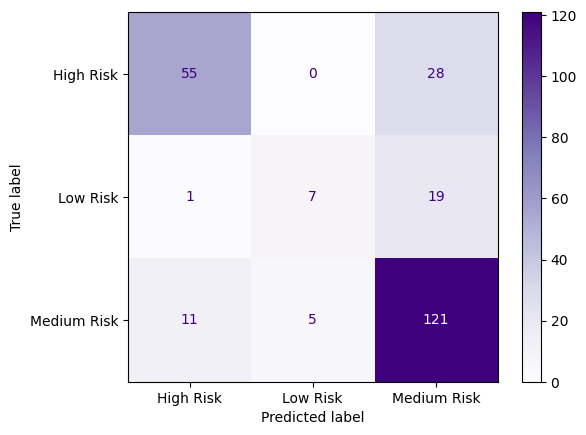

In [ ]:
X = df_model.drop(columns=['Score','Country','Continent/Region','risk_level'])
y = df_model['risk_level']

model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=model2.classes_)
disp2.plot(cmap='Purples')

feature_importance = pd.Series(
    model2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).reset_index()

print(acc,"\n")
print(f"Feature Importance \n {feature_importance}\n")

**Macroeconomic indicators such as inflation volatility effectively identify high-risk countries but are insufficient to distinguish between medium and low-risk categories, suggesting that additional socio-economic factors are required for finer classification.**

# **Applying SMOTE & Retraining the model**
Only Macroeconomic Factors

Accuracy  0.7814
Recall    0.7814
F1 Score  0.7783

Class Distribution Before SMOTE 
    risk_level  count
0  Medium Risk    535
1    High Risk    339
2     Low Risk    111

Class Distribution After SMOTE 
    risk_level  count
0    High Risk    535
1  Medium Risk    535
2     Low Risk    535



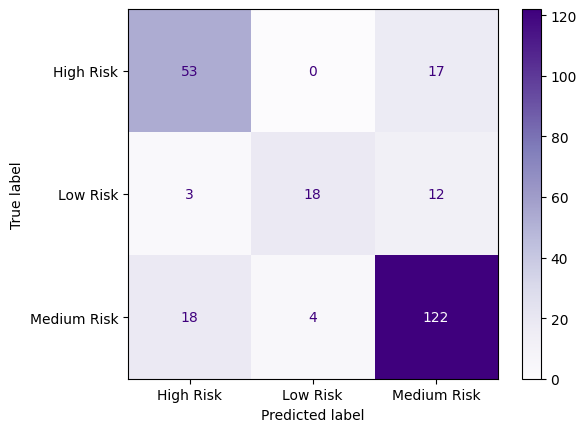

In [ ]:
smote = SMOTE(random_state=42)

X = df_model.drop(columns=['Score','Country','Continent/Region','risk_level'])
y = df_model['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)                                     # Train Test Split

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)                                                           # Applying SMOTE

model3 = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = 'balanced'
)

model3.fit(X_train_smote, y_train_smote)
y_pred = model3.predict(X_test)

cm3 = confusion_matrix(y_pred, y_test)
disp3 = ConfusionMatrixDisplay(cm3, display_labels=model3.classes_)
disp3.plot(cmap='Purples')

print(f"Accuracy  {accuracy_score(y_pred, y_test):.4f}")
print(f"Recall    {recall_score(y_pred, y_test, average='weighted'):.4f}")
print(f"F1 Score  {f1_score(y_pred, y_test, average='weighted'):.4f}\n")
print(f"Class Distribution Before SMOTE \n{y_train.value_counts().reset_index()}\n")
print(f"Class Distribution After SMOTE \n{y_train_smote.value_counts().reset_index()}\n")

**Macroeconomic inflation indicators, even after advanced feature engineering and resampling, are insufficient to fully distinguish between medium and low happiness risk levels due to overlapping economic patterns.**

# **Hybrid Model**
Economic + Social + Governance factors

In [ ]:
df_model2 = df.copy()

# df_model2.to_csv('df_model2.csv', index=False)                                            # Uncomment these 2 line only when you need to download the dataset before removing leakage columns to create the streamlit application on VS CODE
# files.download('df_model2.csv')

leakage_columns = ['GDP per Capita', 'Social support',
                'Healthy life expectancy at birth', 'Generosity']

df_model2 = df_model2.drop(columns=leakage_columns)                                         # Includes Perception of corruption and freedom to make life choices

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Hybrid model Before SMOTE**

Accuracy  0.8442
Recall    0.8442
F1 Score  0.8456
Feature Importance
                                      index         0
0             Freedom to make life choices  0.163987
1                Perceptions of corruption  0.161447
2                 Producer Price Inflation  0.097126
3                     Inflation_volatility  0.097075
4   Official Core Consumer Price Inflation  0.079689
5                inflation_rolling_average  0.069425
6          Energy Consumer Price Inflation  0.061894
7            Food Consumer Price Inflation  0.055493
8        Headline Consumer Price Inflation  0.052459
9                  previous_year_inflation  0.045889
10                        Inflation_change  0.043745
11          GDP deflator Index growth rate  0.043715
12                                    Year  0.028056



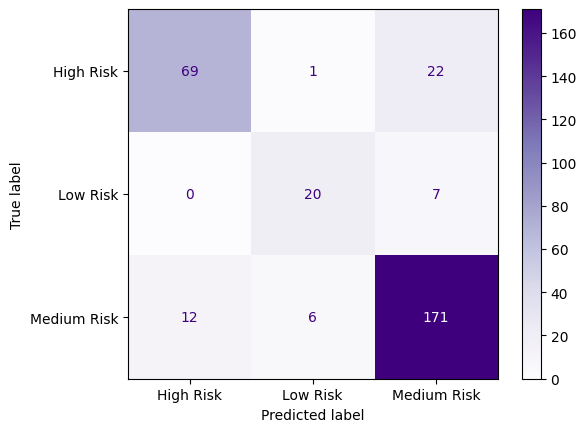

In [ ]:
X = df_model2.drop(columns=['Score', 'Continent/Region', 'Country', 'risk_level'])
y = df_model2['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

before_smote_hybrid_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

before_smote_hybrid_model.fit(X_train, y_train)

y_pred = before_smote_hybrid_model.predict(X_test)

cm4 = confusion_matrix(y_test, y_pred)

feature_importance = pd.Series(
    before_smote_hybrid_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).reset_index()

print(f"Accuracy  {accuracy_score(y_pred, y_test):.4f}")
print(f"Recall    {recall_score(y_pred, y_test, average='weighted'):.4f}")
print(f"F1 Score  {f1_score(y_pred, y_test, average='weighted'):.4f}")
print(f"Feature Importance\n {feature_importance}\n")

disp4 = ConfusionMatrixDisplay(cm4, display_labels=before_smote_hybrid_model.classes_)
disp4.plot(cmap='Purples')

## **Hybrid Model after SMOTE**

Accuracy  0.8084
Recall    0.8084
F1 Score  0.8067
Feature Importance
                                      index         0
0                Perceptions of corruption  0.202431
1             Freedom to make life choices  0.167869
2                     Inflation_volatility  0.108784
3   Official Core Consumer Price Inflation  0.079955
4                 Producer Price Inflation  0.073221
5                inflation_rolling_average  0.070399
6            Food Consumer Price Inflation  0.056212
7          Energy Consumer Price Inflation  0.054759
8        Headline Consumer Price Inflation  0.050555
9                  previous_year_inflation  0.041153
10          GDP deflator Index growth rate  0.040261
11                        Inflation_change  0.032250
12                                    Year  0.022151



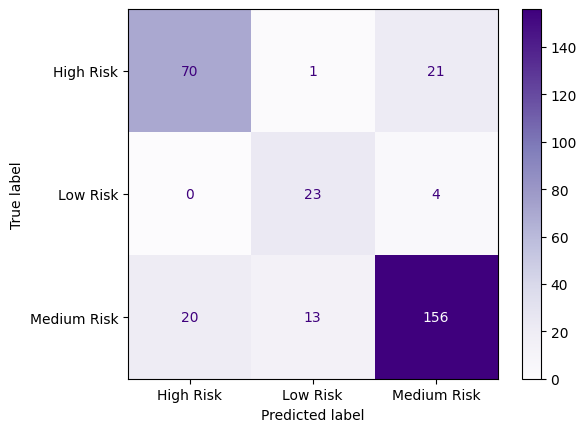

In [ ]:
# Hybrid Model After SMOTE

smote = SMOTE(random_state=42)

X_train_smote_hybrid, y_train_smote_hybrid = smote.fit_resample(X_train, y_train)

after_smote_hybrid_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

after_smote_hybrid_model.fit(X_train_smote_hybrid, y_train_smote_hybrid)

y_pred = after_smote_hybrid_model.predict(X_test)
cm5 = confusion_matrix(y_test, y_pred)

feature_importance = pd.Series(
    after_smote_hybrid_model.feature_importances_,
    index=X_train_smote_hybrid.columns
).sort_values(ascending=False).reset_index()

disp5 = ConfusionMatrixDisplay(cm5, display_labels=after_smote_hybrid_model.classes_)
disp5.plot(cmap='Purples')

print(f"Accuracy  {accuracy_score(y_pred, y_test):.4f}")
print(f"Recall    {recall_score(y_pred, y_test, average='weighted'):.4f}")
print(f"F1 Score  {f1_score(y_pred, y_test, average='weighted'):.4f}")
print(f"Feature Importance\n {feature_importance}\n")

**While macroeconomic indicators like inflation provide insight into economic stability, they are insufficient to fully explain well-being outcomes. Incorporating social and institutional factors significantly enhances predictive performance, highlighting the multidimensional nature of happiness.**

**There exists a trade-off between overall accuracy and class balance. While the baseline hybrid model achieved higher accuracy, applying SMOTE improved minority class detection, making the model more equitable and practically useful.**

## **Model Comparison**

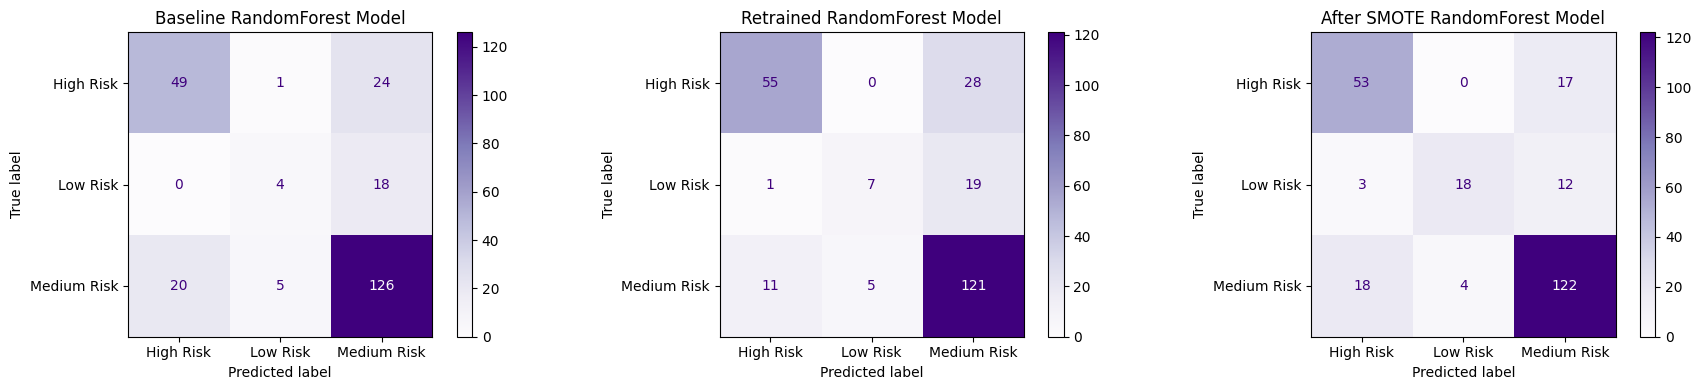

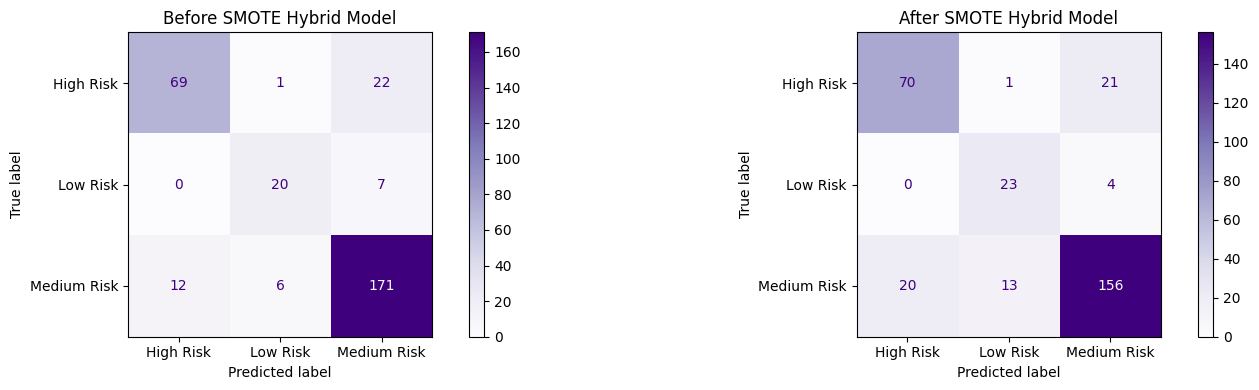

In [ ]:
# Comparing Models

titles = ['Baseline RandomForest Model', 'Retrained RandomForest Model', 'After SMOTE RandomForest Model']
disps = [disp1, disp2, disp3]

fig, axes = plt.subplots(1, len(titles), figsize=(18, 4))

for idx, disp_obj in enumerate(disps):
    disp_obj.plot(cmap='Purples', ax=axes[idx])
    axes[idx].set_title(titles[idx])

plt.tight_layout()
plt.show()
print()

titles2 = ['Before SMOTE Hybrid Model', 'After SMOTE Hybrid Model']
disps2 = [disp4, disp5]

fig, axes = plt.subplots(1, len(disps2), figsize=(15, 4))

for idx, disp2_obj in enumerate(disps2):
    disp2_obj.plot(cmap='Purples', ax=axes[idx])
    axes[idx].set_title(titles2[idx])

plt.tight_layout()
plt.show()